In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.linear_model import LinearRegression

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [5]:
#load all datasets

layoffs = pd.read_csv("C:\\Users\\rites\\Downloads\\archive (9)\\tech_layoffs_2025_2026.csv")
hiring = pd.read_csv("C:\\Users\\rites\\Downloads\\archive (9)\\tech_hiring_trends_2025_2026.csv")
dept = pd.read_csv("C:\\Users\\rites\\Downloads\\archive (9)\\layoffs_department_analysis.csv")
geo = pd.read_csv("C:\\Users\\rites\\Downloads\\archive (9)\\layoffs_geographic_analysis.csv")
industry = pd.read_csv("C:\\Users\\rites\\Downloads\\archive (9)\\layoffs_industry_analysis.csv")
severance = pd.read_csv("C:\\Users\\rites\\Downloads\\archive (9)\\layoffs_severance_analysis.csv")
ai = pd.read_csv("C:\\Users\\rites\\Downloads\\archive (9)\\layoffs_ai_impact_analysis.csv")


In [6]:
layoffs.columns

Index(['Company', 'Employees_Laid_Off', 'Date', 'Industry', 'Location',
       'Country', 'Reason', 'Department', 'Percentage_Workforce',
       'Total_Employees', 'Severance_Weeks', 'AI_Related', 'Year', 'Month',
       'Month_Name', 'Quarter'],
      dtype='object')

In [7]:
# Convert date
layoffs['Date'] = pd.to_datetime(layoffs['Date'], errors='coerce')

# Fill missing values
layoffs.fillna(method='ffill', inplace=True)

# Remove duplicates
layoffs.drop_duplicates(inplace=True)

In [8]:
layoffs.isnull().sum()

Company                 0
Employees_Laid_Off      0
Date                    0
Industry                0
Location                0
Country                 0
Reason                  0
Department              0
Percentage_Workforce    0
Total_Employees         0
Severance_Weeks         0
AI_Related              0
Year                    0
Month                   0
Month_Name              0
Quarter                 0
dtype: int64

In [9]:
hiring.isnull().sum()

Company             0
Role                0
Number_Positions    0
Date_Posted         0
Salary_Min          0
Salary_Max          0
Location            0
Country             0
Remote              0
Skills_Required     0
Experience_Years    0
Department          0
Year                0
Month               0
Salary_Average      0
dtype: int64

In [10]:
#Clean all datasets
datasets = [layoffs, hiring, industry, geo, dept, ai, severance]

for d in datasets:
    d.columns = d.columns.str.strip().str.lower()

In [11]:
#Merge Function
def better_merge(df1, df2):
    # Priority columns
    keys_priority = ['company', 'industry', 'country']
    
    for key in keys_priority:
        if key in df1.columns and key in df2.columns:
            print(f"Merging on: {key}")
            return df1.merge(df2, on=key, how='left')
    
    print(" No suitable key found, skipping dataset")
    return df1

In [12]:
def smart_merge(df1, df2):
    common_cols = list(set(df1.columns).intersection(df2.columns))
    
    if common_cols:
        return df1.merge(df2, on=common_cols, how='left')
    else:
        print("No suitable key found, skipping dataset")
        return df1

In [13]:
#Apply Merge
df = layoffs.copy()

df = smart_merge(df, hiring)
df = smart_merge(df, industry)
df = smart_merge(df, geo)
df = smart_merge(df, dept)
df = smart_merge(df, ai)
df = smart_merge(df, severance)

In [14]:
#df.shap
#df.columns
df.head()

,company,employees_laid_off,date,industry,location,country,reason,department,percentage_workforce,total_employees,...,experience_years,salary_average,total_layoffs,number_companies,avg_workforce_percentage,avg_severance_weeks,percentage_of_total,total_affected,number_events,percentage
0,Duolingo,250,2025-01-08,EdTech,"Pittsburgh, PA",USA,AI replacing content creators,"Content, Marketing",10.0,2500,...,NaN,NaN,250,1,10.0,10.0,NaN,NaN,NaN,NaN
1,Twitch,500,2025-01-09,Live Streaming,"San Francisco, CA",USA,Profitability challenges,"Engineering, Marketing",35.0,1400,...,NaN,NaN,500,1,35.0,14.0,NaN,NaN,NaN,NaN
2,Coinbase,950,2025-01-10,Cryptocurrency,"San Francisco, CA",USA,Crypto market downturn,"Engineering, Marketing",20.0,4750,...,NaN,NaN,950,1,20.0,14.0,NaN,NaN,NaN,NaN
3,Discord,170,2025-01-11,Communication,"San Francisco, CA",USA,Cost reduction,"Support, Marketing",17.0,1000,...,NaN,NaN,170,1,17.0,12.0,NaN,NaN,NaN,NaN
4,Wayfair,1650,2025-01-19,E-commerce,"Boston, MA",USA,Market conditions,"Operations, Support",13.0,12700,...,NaN,NaN,3950,2,18.0,13.0,NaN,NaN,NaN,NaN


In [15]:
for d in [layoffs, hiring, industry, geo, dept, ai, severance]:
    d.columns = d.columns.str.strip().str.lower()
    
    if 'company' in d.columns:
        d['company'] = d['company'].str.lower().str.strip()

In [16]:
#Handle Remaining NaN Values
df.fillna(0, inplace=True)
df.fillna("Unknown", inplace=True)
df.fillna("Unknown", inplace=True)

In [17]:
print(df.isnull().sum())

company                     0
employees_laid_off          0
date                        0
industry                    0
location                    0
country                     0
reason                      0
department                  0
percentage_workforce        0
total_employees             0
severance_weeks             0
ai_related                  0
year                        0
month                       0
month_name                  0
quarter                     0
role                        0
number_positions            0
date_posted                 0
salary_min                  0
salary_max                  0
remote                      0
skills_required             0
experience_years            0
salary_average              0
total_layoffs               0
number_companies            0
avg_workforce_percentage    0
avg_severance_weeks         0
percentage_of_total         0
total_affected              0
number_events               0
percentage                  0
dtype: int

In [18]:
df.columns

Index(['company', 'employees_laid_off', 'date', 'industry', 'location',
       'country', 'reason', 'department', 'percentage_workforce',
       'total_employees', 'severance_weeks', 'ai_related', 'year', 'month',
       'month_name', 'quarter', 'role', 'number_positions', 'date_posted',
       'salary_min', 'salary_max', 'remote', 'skills_required',
       'experience_years', 'salary_average', 'total_layoffs',
       'number_companies', 'avg_workforce_percentage', 'avg_severance_weeks',
       'percentage_of_total', 'total_affected', 'number_events', 'percentage'],
      dtype='object')

In [19]:
#Feature Engineering
# Date features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Layoff intensity
df['layoff_ratio'] = df['employees_laid_off'] / df['employees_laid_off'].max()

# Hiring vs Layoff ratio
df['hire_layoff_ratio'] = df['number_positions'] / (df['employees_laid_off'] + 1)

In [20]:
#Encode Data
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

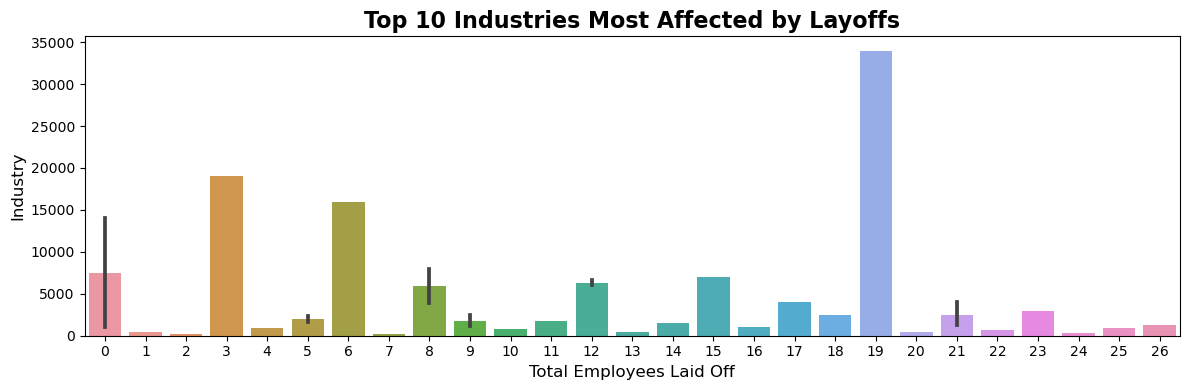

In [21]:
#visualization
#1.Which industries are most affected by layoffs, and how does the distribution of layoffs vary across different industries?
plt.figure(figsize=(12,4))
sns.barplot(x='industry', y='employees_laid_off', data=df)
plt.title("Top 10 Industries Most Affected by Layoffs", fontsize=16, fontweight='bold')
plt.xlabel("Total Employees Laid Off", fontsize=12)
plt.ylabel("Industry", fontsize=12)
plt.tight_layout()
plt.show()

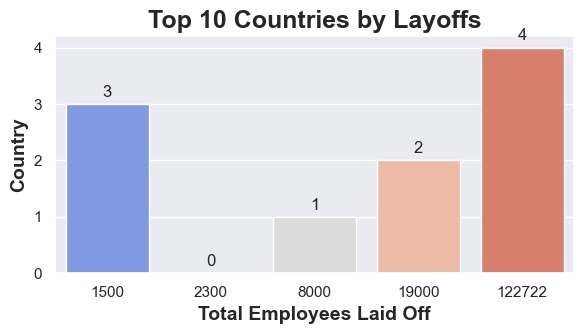

In [35]:
#2How do layoffs vary across different geographic locations, and which regions experience the highest workforce reductions?
top_countries = (df.groupby('country')['employees_laid_off'].sum().sort_values(ascending=False)
.head(10).reset_index())

plt.figure(figsize=(6,3.5))
ax = sns.barplot(x='employees_laid_off',y='country',data=top_countries,palette='coolwarm')
for i in ax.containers:
    ax.bar_label(i, fmt='%d', padding=3)

plt.title("Top 10 Countries by Layoffs", fontsize=18, fontweight='bold')
plt.xlabel("Total Employees Laid Off",fontsize=14,fontweight='bold')
plt.ylabel("Country",fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()


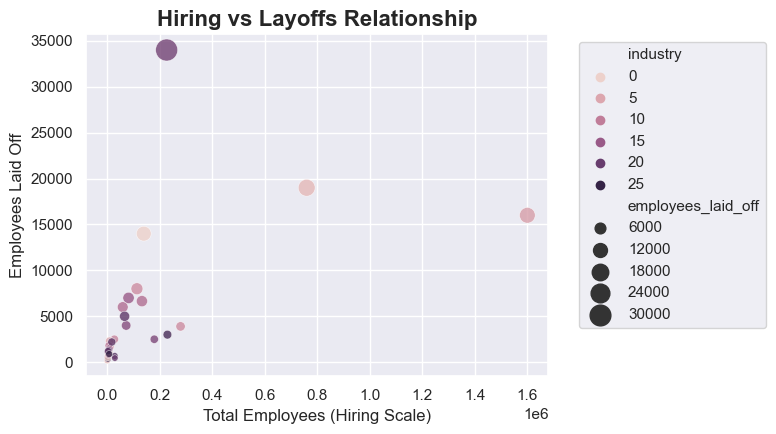

In [38]:
#3 What is the relationship between hiring trends and layoffs, and do companies that hire more also tend to lay off more employees?
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8,4.5))
sns.scatterplot(data=df,x='total_employees',y='employees_laid_off',hue='industry',size='employees_laid_off',  sizes=(20,250),alpha=0.8)
plt.title("Hiring vs Layoffs Relationship", fontsize=16, fontweight='bold')
plt.xlabel("Total Employees (Hiring Scale)")
plt.ylabel("Employees Laid Off")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

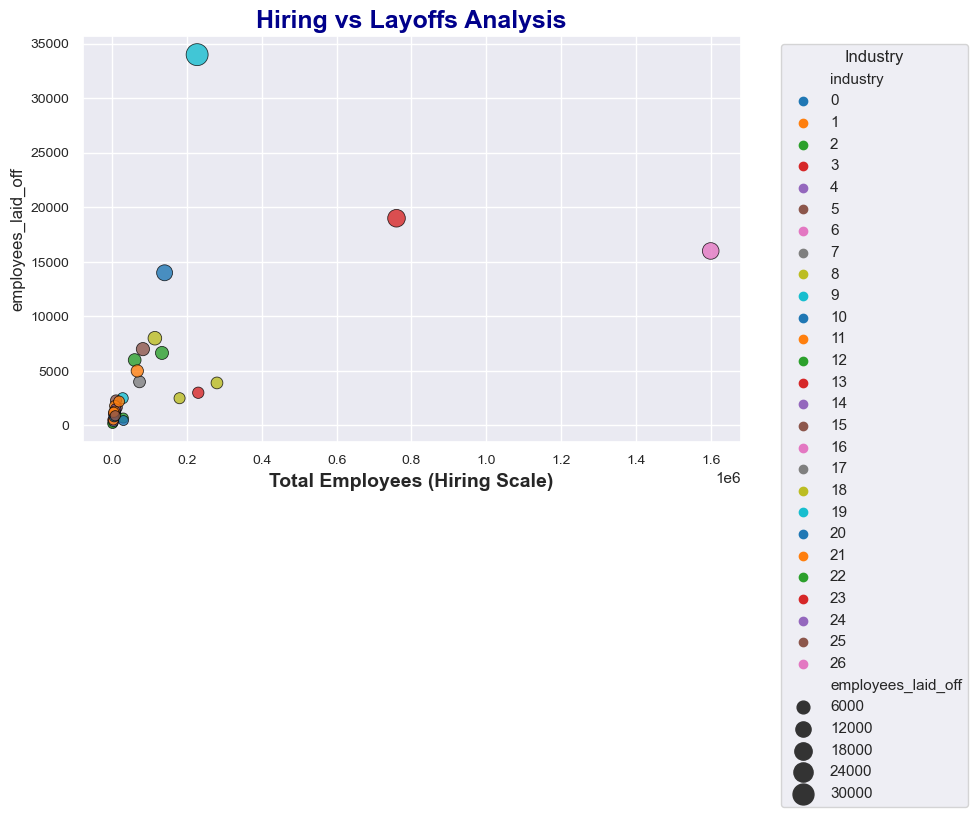

In [40]:
#4 How does AI adoption influence layoffs, and are AI-related layoffs significantly higher compared to non-AI-related layoffs?
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10,7))
sns.scatterplot(data=df,x='total_employees',y='employees_laid_off',hue='industry',palette='tab10',size='employees_laid_off',  sizes=(50, 250),alpha=0.8,edgecolor='black')
plt.title("Hiring vs Layoffs Analysis",fontsize=18,fontweight='bold',color='darkblue')
plt.xlabel("Total Employees (Hiring Scale)",fontsize=14,fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1),loc='upper left',title="Industry",title_fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

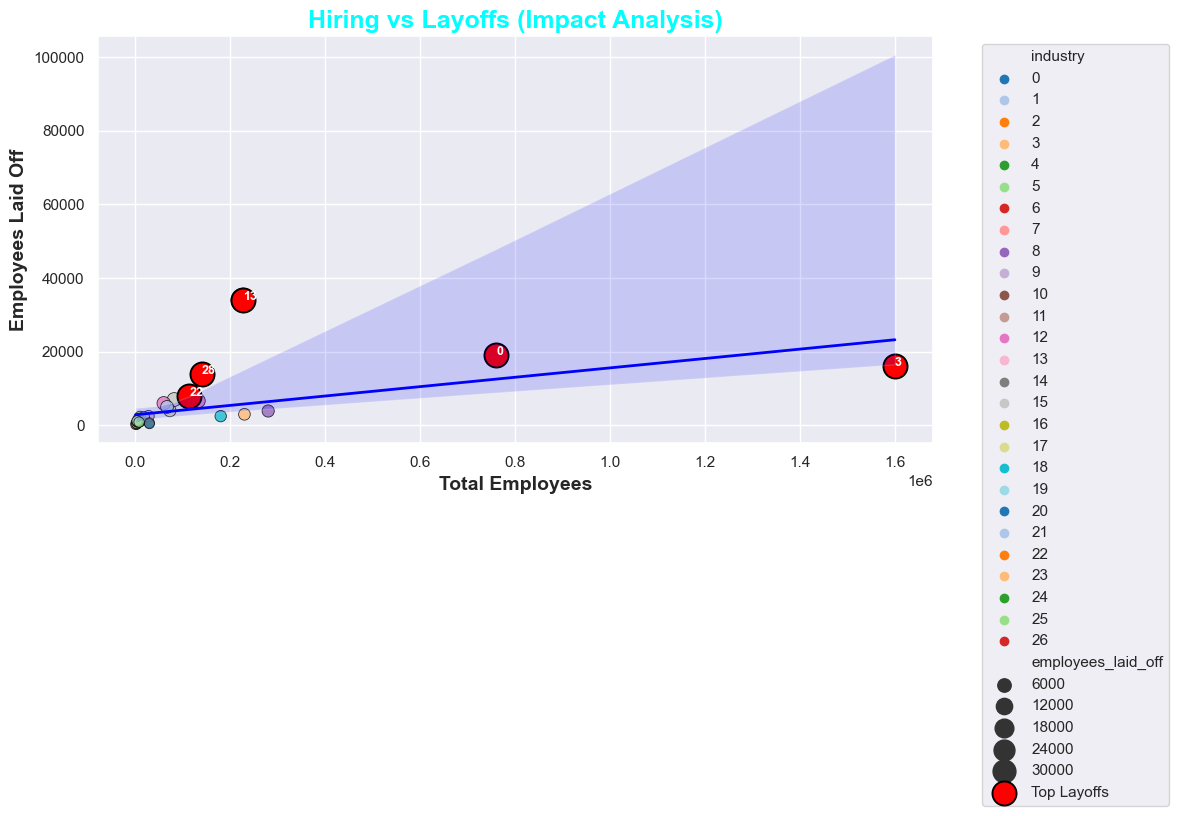

In [41]:
#5 How does AI adoption influence hiring trends, and do companies investing in AI show different hiring patterns compared to non-AI companies?
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12,7))
ax = sns.scatterplot(data=df,x='total_employees',y='employees_laid_off',hue='industry',
    size='employees_laid_off',sizes=(50, 300),palette='tab20',alpha=0.8,edgecolor='black')

# TOP 5 layoffs
top5 = df.nlargest(5, 'employees_laid_off')
sns.scatterplot(data=top5,x='total_employees',y='employees_laid_off',color='red',
    s=300,edgecolor='black',label='Top Layoffs')

for i in range(len(top5)):
    plt.text(top5.iloc[i]['total_employees'],top5.iloc[i]['employees_laid_off'],
        top5.iloc[i]['company'],fontsize=9,weight='bold',color='white')

# Trend line
sns.regplot(data=df,x='total_employees',y='employees_laid_off',scatter=False,
            color='blue',line_kws={'linewidth':2})
\
plt.title("Hiring vs Layoffs (Impact Analysis)", fontsize=18, fontweight='bold', color='cyan')
plt.xlabel("Total Employees", fontsize=14, fontweight='bold')
plt.ylabel("Employees Laid Off", fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

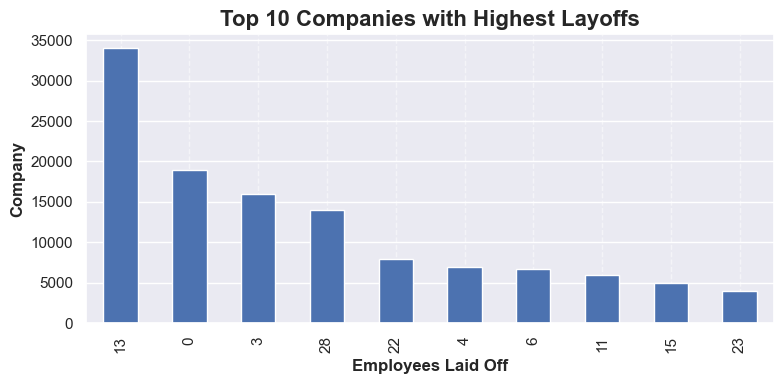

In [43]:
#6. Which companies have experienced the highest number of layoffs, and what patterns can be observed among these companies?”
top_companies = df.groupby('company')['employees_laid_off'].sum().sort_values(ascending=False).head(10)
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8,4))
top_companies.plot(kind='bar')
plt.title("Top 10 Companies with Highest Layoffs",fontsize=16,fontweight='bold')
plt.xlabel("Employees Laid Off", fontsize=12, fontweight='bold')
plt.ylabel("Company", fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


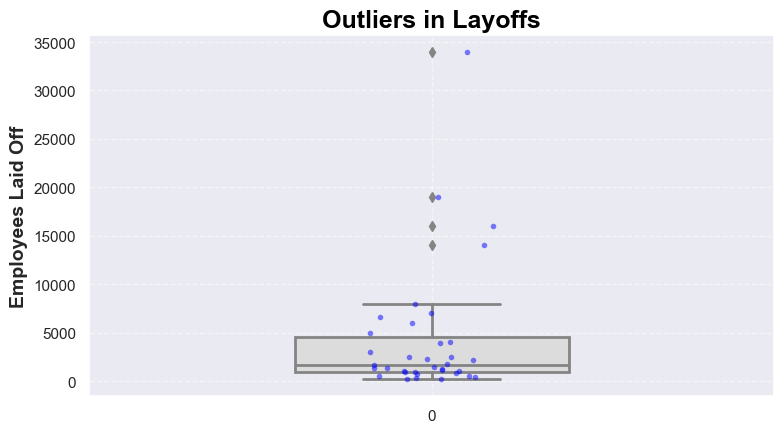

In [48]:
#7.Are there any extreme or unusual layoff events in the dataset, and what factors contribute to these outliers?
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8,4.5))
sns.boxplot(df['employees_laid_off'],palette='coolwarm',width=0.4,linewidth=2)
sns.stripplot(y='employees_laid_off',data=df,color='blue',alpha=0.5,jitter=True,size=4)
plt.title("Outliers in Layoffs",  fontsize=18,fontweight='bold',color='black')
plt.ylabel("Employees Laid Off", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [28]:
#Predicting AI-Driven Layoffs Using Machine Learning Techniques?
y = df['ai_related'].astype(int)
X = df.drop(['ai_related', 'company', 'location', 'reason', 'date'], axis=1)
X = pd.get_dummies(X)
X = X.fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestClassifier()
model.fit(X_train, y_train)
print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Accuracy: 0.42857142857142855


In [29]:
#Predicting Employee Severance Packages Using Machine Learning
df.columns = df.columns.str.strip()
y = df['severance_weeks']
X = df.drop(columns=['severance_weeks', 'date'], errors='ignore')
X = pd.get_dummies(X)
X = X.fillna(0)
y = y.fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

RMSE: 1.405336766960656


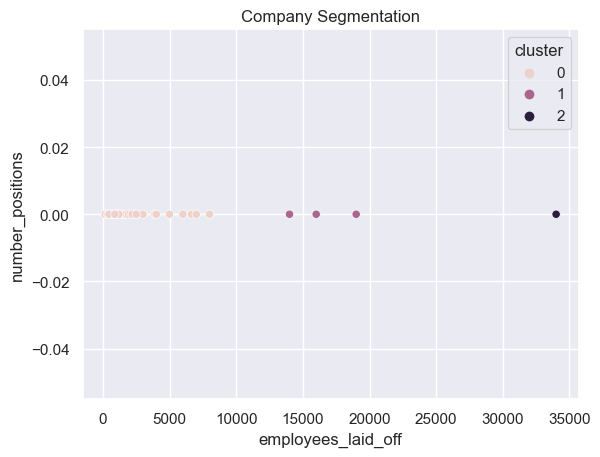

In [30]:
#Company Segmentation Based on Layoffs and Hiring Patterns Using KMeans Clustering?
from sklearn.cluster import KMeans
X_cluster = df[['employees_laid_off','number_positions']]
kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(X_cluster)

sns.scatterplot(x='employees_laid_off', y='number_positions', hue='cluster', data=df)
plt.title("Company Segmentation")
plt.show()

2026-03-31    11940.105978
2026-04-30    11414.453286
2026-05-31    11503.582740
2026-06-30    11488.469986
2026-07-31    11491.032498
2026-08-31    11490.598000
2026-09-30    11490.671673
2026-10-31    11490.659181
2026-11-30    11490.661299
2026-12-31    11490.660940
Freq: M, Name: predicted_mean, dtype: float64


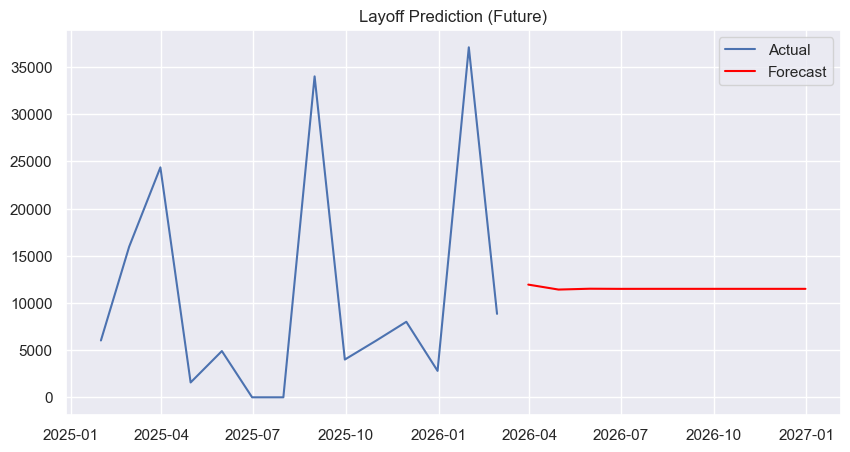

In [31]:
#Time Series Analysis of Employee Layoffs Trends Over Time?
ts = df.groupby('date')['employees_laid_off'].sum().reset_index()
ts.set_index('date',inplace =True)
ts = ts.resample('M').sum() 

from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=10)  
print(forecast)

plt.figure(figsize=(10,5))
plt.plot(ts, label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.title("Layoff Prediction (Future)")
plt.show()

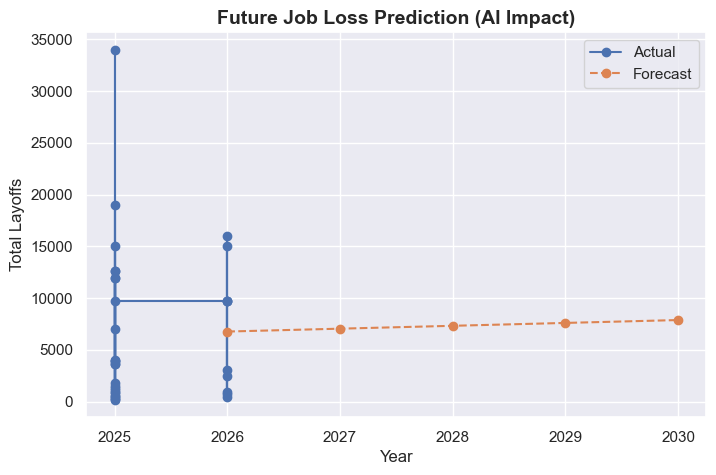

In [32]:
#How does the number of layoffs change over time, and what will be the expected layoffs in the next 5 years?

# Fix column names
df.columns = df.columns.str.strip().str.lower()

# Correct columns
X = df[['year']]
y = df['total_layoffs']

# Model
model = LinearRegression()
model.fit(X, y)

# Future prediction
future_years = np.array([2026, 2027, 2028, 2029, 2030]).reshape(-1,1)
future_predictions = model.predict(future_years)

# Plot
plt.figure(figsize=(8,5))
plt.plot(df['year'], df['total_layoffs'], label='Actual', marker='o')
plt.plot(future_years.flatten(), future_predictions, label='Forecast', linestyle='--', marker='o')
plt.title("Future Job Loss Prediction (AI Impact)", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Total Layoffs")
plt.legend()
plt.show()

In [33]:
#Find total layoffs, most affected industry, top country, and average severance?
print("Total Layoffs:", df['employees_laid_off'].sum())
print("Top Industry:", df['industry'].mode()[0])
print("Top Country:", df['country'].mode()[0])
print("Average Severance:", df['severance_weeks'].mean())

Total Layoffs: 153522
Top Industry: 21
Top Country: 4
Average Severance: 12.17142857142857
